# Churn Prediction MLOps Pipeline
## Phase 1: Data Preparation
This notebook loads the Telco Customer Churn dataset from Google Cloud Storage,
performs exploratory data analysis, preprocesses the features, and saves
train/test splits back to GCS for use in the Vertex AI training job.

Running on Vertex AI Workbench — credentials are inherited automatically from GCP.

In [1]:
PROJECT_ID = "churn-mlops"
BUCKET_NAME = "churn-mlops-bucket-caston"
REGION = "us-central1"

import subprocess
result = subprocess.run(
    ["gcloud", "storage", "ls", f"gs://{BUCKET_NAME}"],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

gs://churn-mlops-bucket-caston/WA_Fn-UseC_-Telco-Customer-Churn.csv
gs://churn-mlops-bucket-caston/data/




## Load Data
We read the raw CSV directly from GCS rather than storing it locally.
In production ML pipelines, data always lives in cloud storage so it's
accessible to training jobs, notebooks, and pipelines alike.

In [2]:
import pandas as pd

df = pd.read_csv(f"gs://{BUCKET_NAME}/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Exploratory Data Analysis
Before preprocessing, we inspect the data to understand feature types,
missing values, and the distribution of our target variable (Churn).
A 73/27 class imbalance means we'll need to account for this during
model training.

Data types:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
 Series([], dtype: int64)

Churn distribution:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64


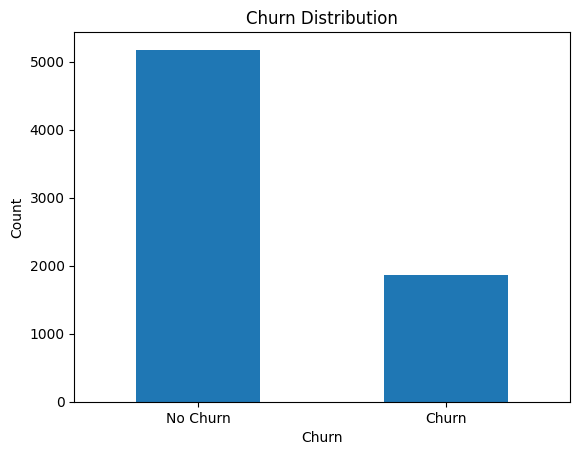

In [3]:
import matplotlib.pyplot as plt

# Data types and nulls
print("Data types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nChurn distribution:\n", df['Churn'].value_counts())

# Visualize class balance
df['Churn'].value_counts().plot(kind='bar', title='Churn Distribution')
plt.xticks([0, 1], ['No Churn', 'Churn'], rotation=0)
plt.ylabel('Count')
plt.show()

## Preprocessing
Raw data is rarely ready for a model as-is. We need to:
1. Fix TotalCharges — it's a string column because some rows have blank spaces instead of numbers
2. Drop customerID — it's just a unique identifier, it has no predictive signal
3. Encode the target — convert Churn from Yes/No to 1/0
4. Label encode categoricals — convert all remaining string columns to numbers
5. Drop the 11 rows with nulls introduced by the TotalCharges conversion

Each of these steps is standard practice in any real ML pipeline.

In [4]:
import pandas as pd
import numpy as np

# Step 1: Fix TotalCharges
# pd.to_numeric converts the column to numbers.
# errors='coerce' means "if you can't convert a value, turn it into NaN"
# instead of throwing an error. This catches the blank space rows.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now check for nulls again — you should see 11 this time
print("Missing values after conversion:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values after conversion:
TotalCharges    11
dtype: int64


In [5]:
# Step 2: Drop the 11 rows with nulls
# These are customers with no TotalCharges recorded.
# 11 rows out of 7,043 is 0.15% of the data — not worth trying to impute,
# just drop them.
df = df.dropna()

print(f"Shape after dropping nulls: {df.shape}")
# Should be (7032, 21)

Shape after dropping nulls: (7032, 21)


In [6]:
# Step 3: Drop customerID
# customerID is just a unique identifier assigned to each customer.
# It has no relationship to whether someone churns or not —
# it's essentially a random string. If we left it in, the model
# might try to find patterns in it, which would just be noise.
df = df.drop(columns=['customerID'])

print(f"Shape after dropping customerID: {df.shape}")
# Should be (7032, 20) — one less column

Shape after dropping customerID: (7032, 20)


In [7]:
# Step 4: Encode the target variable
# Our target column 'Churn' contains the strings 'Yes' and 'No'.
# Models need numbers, so we convert it to 1 (churned) and 0 (did not churn).
# This is called binary encoding since there are only two possible values.
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print("Churn value counts after encoding:")
print(df['Churn'].value_counts())

Churn value counts after encoding:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [9]:
# Step 5: Label encode categorical columns
# Most of our remaining columns are still strings (object type) —
# things like gender, Contract, PaymentMethod, InternetService, etc.
# Models can't do math on strings, so we convert each unique string
# value to a number. This is called label encoding.
#
# For example, Contract has three values:
#   'Month-to-month' -> 0
#   'One year'       -> 1
#   'Two year'       -> 2
#
# LabelEncoder does this automatically for every unique value in a column.

from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include='str').columns
print("Columns being encoded:", list(cat_cols))

for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

print("\nSample of encoded data:")
print(df.head())

Columns being encoded: []

Sample of encoded data:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0           

## Train/Test Split
Once the data is clean and encoded, we split it into two sets before
touching any model code.

**Training set (80%):** The model learns from this data — it sees the
features and the correct churn labels and finds patterns.

**Test set (20%):** Held out completely until after training. We use it
to evaluate whether the model actually learned something useful, or just
memorized the training data. This is called generalization.

`stratify=y` ensures both splits maintain the same churn ratio so
neither set is accidentally over or under-represented with churners.

`random_state=42` makes the split deterministic — you get the same
split every time you run the notebook, which is important for
reproducibility.

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])  # features — everything except the target
y = df['Churn']                  # target — what we're trying to predict

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size:     {X_test.shape}")
print(f"\nChurn rate in training set: {y_train.mean():.2%}")
print(f"Churn rate in test set:     {y_test.mean():.2%}")

Training set size: (5625, 19)
Test set size:     (1407, 19)

Churn rate in training set: 26.58%
Churn rate in test set:     26.58%


## Save Splits to GCS
We save the processed train and test sets back to our GCS bucket.
This is standard MLOps practice — data lives in cloud storage, not
locally, so it's accessible to training jobs, pipelines, and other
services later in the workflow.

In [12]:
# Reassemble train and test dataframes with the target column included
train_df = X_train.copy()
train_df['Churn'] = y_train

test_df = X_test.copy()
test_df['Churn'] = y_test

# Save to GCS
train_df.to_csv(f"gs://{BUCKET_NAME}/data/train.csv", index=False)
test_df.to_csv(f"gs://{BUCKET_NAME}/data/test.csv", index=False)

print("Saved to GCS:")
print(f"  gs://{BUCKET_NAME}/data/train.csv")
print(f"  gs://{BUCKET_NAME}/data/test.csv")

Saved to GCS:
  gs://churn-mlops-bucket-caston/data/train.csv
  gs://churn-mlops-bucket-caston/data/test.csv
